# Задача

Реализовать класс `MyBinaryLogisticRegression` для работы с логистической регрессией. Обеспечить возможность использования `l1`, `l2` и `l1l2` регуляризации и реализовать слудующие методы решения оптимизационной задачи:

*   Градиентный спуск
*   Стохастический градиентный спуск
*   Метод Ньютона

Обосновать применимость/не применимость того или иного метода оптимизации в случае использованного типа регуляризации.



In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler

In [78]:
class MyBinaryLogisticRegression:
    def __init__(self, method='gd', penalty='l2', C=1.0, l1_ratio=0.5, 
                 max_iter=1000, learning_rate=0.01, tol=1e-4, 
                 batch_size=32, random_state=None):
        """
        Параметры:
        ----------
        method : {'gd', 'sgd', 'newton'}
            Метод оптимизации
        penalty : {'l2', 'l1', 'elasticnet', 'none'}
            Тип регуляризации
        C : float
            Обратная сила регуляризации (1/λ). Меньше C -> сильнее регуляризация
        l1_ratio : float [0, 1]
            Для elasticnet: доля L1 регуляризации (0 = только L2, 1 = только L1)
        max_iter : int
            Максимальное число итераций
        learning_rate : float
            Скорость обучения для градиентного спуска
        tol : float
            Критерий остановки (изменение функции потерь)
        batch_size : int
            Размер батча для SGD
        random_state : int
            Seed для воспроизводимости
        """
        self.coefs_ = None
        self.intercept_ = None
        self.feature_names_in_ = None
        self.method = method
        self.penalty = penalty
        self.C = C  # C = 1/λ
        self.l1_ratio = l1_ratio
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.tol = tol
        self.batch_size = batch_size
        self.random_state = random_state
        self.loss_history_ = []
        
        if random_state is not None:
            np.random.seed(random_state)
    
    def _add_intercept(self, X):
        """Добавляет столбец единиц для intercept"""
        return np.hstack((np.ones((X.shape[0], 1)), X))
    
    def _sigmoid(self, z):
        """Сигмоидная функция"""
        # Более устойчивая реализация
        z = np.clip(z, -500, 500)  # Избегаем переполнения
        return 1 / (1 + np.exp(-z))
    
    def get_sigmoid(self, X, W):
        """Вычисление сигмоиды для каждого объекта"""
        z = X @ W
        return self._sigmoid(z)
    
    def _regularization_penalty(self, W):
        """Вычисляет штраф регуляризации"""
        # Пропускаем intercept (первый коэффициент)
        W_without_intercept = W[1:] if len(W) > 1 else W
        
        if len(W_without_intercept) == 0:
            return 0
            
        if self.penalty == 'l2':
            penalty = 0.5 * np.sum(W_without_intercept ** 2)
        elif self.penalty == 'l1':
            penalty = np.sum(np.abs(W_without_intercept))
        elif self.penalty == 'elasticnet':
            l1_penalty = np.sum(np.abs(W_without_intercept))
            l2_penalty = 0.5 * np.sum(W_without_intercept ** 2)
            penalty = self.l1_ratio * l1_penalty + (1 - self.l1_ratio) * l2_penalty
        else:  # 'none'
            penalty = 0
            
        return penalty
    
    def _regularization_gradient(self, W):
        """Вычисляет градиент штрафа регуляризации"""
        n_features = len(W)
        grad = np.zeros(n_features)
        
        # Не регуляризуем intercept
        start_idx = 1 if n_features > 1 else 0
        
        if self.penalty == 'l2' and start_idx < n_features:
            grad[start_idx:] = W[start_idx:]  # Для L2: градиент = w
        elif self.penalty == 'l1' and start_idx < n_features:
            # Субградиент для L1
            grad[start_idx:] = np.sign(W[start_idx:])
            # Обработка случая w=0
            grad[start_idx:][W[start_idx:] == 0] = 0
        elif self.penalty == 'elasticnet' and start_idx < n_features:
            l1_grad = np.sign(W[start_idx:])
            l1_grad[W[start_idx:] == 0] = 0
            l2_grad = W[start_idx:]
            grad[start_idx:] = (self.l1_ratio * l1_grad + 
                               (1 - self.l1_ratio) * l2_grad)
        
        return grad
    
    def get_loss(self, X, Y, W):
        """Вычисление функции потерь с регуляризацией"""
        n_samples = X.shape[0]
        sigmoid = self.get_sigmoid(X, W)
        
        # Основная функция потерь (negative log likelihood)
        epsilon = 1e-15  # Для численной устойчивости
        sigmoid = np.clip(sigmoid, epsilon, 1 - epsilon)
        
        loss = -np.mean(Y * np.log(sigmoid) + (1 - Y) * np.log(1 - sigmoid))
        
        # Добавляем регуляризацию
        reg_penalty = self._regularization_penalty(W)
        loss += reg_penalty / (self.C * n_samples) if self.C > 0 else 0
        
        return loss
    
    def get_grad(self, X, Y, W):
        """Вычисление градиента с регуляризацией"""
        n_samples = X.shape[0]
        sigmoid = self.get_sigmoid(X, W)
        
        # Градиент основной функции
        # grad = X.T @ (sigmoid - Y) / n_samples
        grad = X.T @ (sigmoid - Y)
        
        # Добавляем градиент регуляризации
        if self.C > 0:
            reg_grad = self._regularization_gradient(W)
            # grad += reg_grad / (self.C * n_samples)
            grad += reg_grad / (self.C)
        
        return grad
    
    def get_hess_inv(self, X, W):
        """Вычисление обратной матрицы Гессе с регуляризацией"""
        n_samples = X.shape[0]
        sigmoid = self.get_sigmoid(X, W)
        
        # Диагональная матрица весов
        S = np.diag(sigmoid * (1 - sigmoid))
        
        # Матрица Гессе (без регуляризации)
        # H = X.T @ S @ X / n_samples
        H = X.T @ S @ X
        
        # Добавляем регуляризацию для L2/elasticnet
        if self.penalty in ['l2', 'elasticnet'] and self.C > 0:
            n_features = X.shape[1]
            reg_matrix = np.eye(n_features)
            if n_features > 1:  # Не регуляризуем intercept
                reg_matrix[0, 0] = 0
            # H += reg_matrix / (self.C * n_samples)
            H += reg_matrix / (self.C)
        
        # Для L1 регуляризации матрица Гессе не определена в нуле,
        # используем псевдообратную
        try:
            H_inv = np.linalg.inv(H)
        except np.linalg.LinAlgError:
            # Если матрица вырождена, используем псевдообратную
            H_inv = np.linalg.pinv(H)
        
        return H_inv
    
    def gd(self, X, Y):
        """Градиентный спуск"""
        _, n_features = X.shape
        W = np.random.normal(0, 0.01, size=n_features)
        
        for i in range(self.max_iter):
            loss = self.get_loss(X, Y, W)
            self.loss_history_.append(loss)
            
            # Проверка сходимости
            if i > 0 and abs(self.loss_history_[-2] - loss) < self.tol:
                print(f"GD сошелся за {i+1} итераций")
                break
            
            gradient = self.get_grad(X, Y, W)
            W -= self.learning_rate * gradient
        
        return W
    
    def sgd(self, X, Y):
        """Стохастический градиентный спуск"""
        n_samples, n_features = X.shape
        W = np.random.normal(0, 0.01, size=n_features)
        
        for epoch in range(self.max_iter):
            # Перемешиваем данные
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]
            
            epoch_loss = 0
            
            # Проход по батчам
            for i in range(0, n_samples, self.batch_size):
                batch_end = min(i + self.batch_size, n_samples)
                X_batch = X_shuffled[i:batch_end]
                Y_batch = Y_shuffled[i:batch_end]
                
                # Вычисляем градиент на батче
                gradient = self.get_grad(X_batch, Y_batch, W)
                
                # Обновляем веса
                W -= self.learning_rate * gradient
                
                # Вычисляем loss на батче
                batch_loss = self.get_loss(X_batch, Y_batch, W)
                epoch_loss += batch_loss * (batch_end - i)
            
            # Средний loss за эпоху
            epoch_loss /= n_samples
            self.loss_history_.append(epoch_loss)
            
            # Проверка сходимости
            if epoch > 0 and abs(self.loss_history_[-2] - epoch_loss) < self.tol:
                print(f"SGD сошелся за {epoch+1} эпох")
                break
        
        return W
    
    def newton(self, X, Y):
        """Метод Ньютона"""
        _, n_features = X.shape
        W = np.random.normal(0, 0.01, size=n_features)
        
        for i in range(self.max_iter):
            loss = self.get_loss(X, Y, W)
            self.loss_history_.append(loss)
            
            # Проверка сходимости
            if i > 0 and abs(self.loss_history_[-2] - loss) < self.tol:
                print(f"Newton сошелся за {i+1} итераций")
                break
            
            gradient = self.get_grad(X, Y, W)
            hess_inv = self.get_hess_inv(X, W)
            
            # Обновление весов методом Ньютона
            W -= hess_inv @ gradient
        
        return W
    
    def fit(self, X, y):
        """
        Обучение модели
        
        Parameters:
        -----------
        X : array-like формы (n_samples, n_features)
        y : array-like формы (n_samples,)
        
        Returns:
        --------
        self : объект
        """
        # Проверка и преобразование входных данных
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.tolist()
            X = X.values
        else:
            X = np.array(X)
            
        if isinstance(y, pd.Series):
            y = y.values
        else:
            y = np.array(y)
        
        # Добавляем intercept
        X_with_intercept = self._add_intercept(X)
        
        # Выбираем метод оптимизации
        if self.method == 'gd':
            W = self.gd(X_with_intercept, y)
        elif self.method == 'sgd':
            W = self.sgd(X_with_intercept, y)
        elif self.method == 'newton':
            W = self.newton(X_with_intercept, y)
        else:
            raise ValueError(f"Неизвестный метод: {self.method}")
        
        # Сохраняем коэффициенты
        self.intercept_ = W[0]
        self.coefs_ = W[1:] if len(W) > 1 else np.array([])
        
        return self
    
    def predict_proba(self, X):
        """
        Предсказание вероятностей
        
        Parameters:
        -----------
        X : array-like формы (n_samples, n_features)
        
        Returns:
        --------
        proba : array формы (n_samples, 2)
            Вероятности классов [P(y=0), P(y=1)]
        """
        if isinstance(X, pd.DataFrame):
            X = X.values
        else:
            X = np.array(X)
        
        if self.coefs_ is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")
        
        # Добавляем intercept
        X_with_intercept = self._add_intercept(X)
        W = np.concatenate([[self.intercept_], self.coefs_])
        
        # Вычисляем вероятности для класса 1
        proba_positive = self.get_sigmoid(X_with_intercept, W)
        proba_negative = 1 - proba_positive
        
        return np.column_stack([proba_negative, proba_positive])
    
    def predict(self, X, threshold=0.5):
        """
        Предсказание классов
        
        Parameters:
        -----------
        X : array-like формы (n_samples, n_features)
        threshold : float
            Порог для бинаризации вероятностей
        
        Returns:
        --------
        y_pred : array формы (n_samples,)
            Предсказанные классы (0 или 1)
        """
        proba = self.predict_proba(X)
        return (proba[:, 1] >= threshold).astype(int)
    
    def score(self, X, y, sample_weight=None):
        """
        Вычисление accuracy
        
        Parameters:
        -----------
        X : array-like формы (n_samples, n_features)
        y : array-like формы (n_samples,)
        sample_weight : array-like формы (n_samples,), optional
            Веса объектов
        
        Returns:
        --------
        score : float
            Accuracy модели
        """
        y_pred = self.predict(X)
        
        if sample_weight is not None:
            # Взвешенная accuracy
            correct = (y_pred == y).astype(float)
            return np.average(correct, weights=sample_weight)
        else:
            return np.mean(y_pred == y)
    
    def log_loss(self, X, y):
        """
        Вычисление логарифмической потери
        
        Parameters:
        -----------
        X : array-like формы (n_samples, n_features)
        y : array-like формы (n_samples,)
        
        Returns:
        --------
        loss : float
            Log loss
        """
        proba = self.predict_proba(X)
        epsilon = 1e-15
        proba = np.clip(proba, epsilon, 1 - epsilon)
        
        # Log loss для бинарной классификации
        loss = -np.mean(y * np.log(proba[:, 1]) + 
                       (1 - y) * np.log(proba[:, 0]))
        return loss
    
    def plot_loss_history(self):
        """Визуализация истории потерь"""
        if not self.loss_history_:
            print("Модель еще не обучена")
            return
        
        plt.figure(figsize=(10, 6))
        plt.plot(self.loss_history_, label='Loss')
        plt.xlabel('Iteration/Epoch')
        plt.ylabel('Loss')
        plt.title(f'Loss History ({self.method} method, {self.penalty} penalty)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

Продемонстрировать применение реализованного класса на датасете про пингвинов (целевая переменная — вид пингвина). Рассмотреть все возможные варианты (регуляризация/оптимизация). Для категориального признака `island` реализовать самостоятельно преобразование `Target Encoder`, сравнить результаты классификации с `one-hot`. В качестве метрики использовать `f1-score`.

In [79]:
df = pd.read_csv('./data/data.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2007


In [80]:
df['species'].unique(), df['island'].unique()

(array(['Adelie', 'Gentoo'], dtype=object),
 array(['Torgersen', 'Biscoe', 'Dream'], dtype=object))

In [81]:
y = (df["species"] == "Adelie").astype(int)
X_base = df.drop(columns=["species"]).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size = 0.2, random_state = 42, stratify = y
)

In [84]:
def target_encode_train_test(train_cat: pd.Series, y_train: pd.Series, test_cat: pd.Series):
    """Среднее кодирование целевой переменной (без сглаживания).

    Для каждой категории c:
      enc(c) = mean(y_train | train_cat == c)

    Маппинг обучаем ТОЛЬКО на train, чтобы избежать утечки.
    Неизвестные категории в test заполняем глобальным средним.
    """
    global_mean = float(y_train.mean())
    mapping = (
        pd.DataFrame({"cat": train_cat, "y": y_train})
        .groupby("cat")["y"]
        .mean()
        .to_dict()
    )

    train_enc = train_cat.map(mapping).fillna(global_mean).astype(float)
    test_enc = test_cat.map(mapping).fillna(global_mean).astype(float)

    return train_enc, test_enc, mapping, global_mean

In [85]:
# 1) Target Encoding (таргет-энкодинг)
X_train_te = X_train.copy()
X_test_te = X_test.copy()

X_train_te["island"], X_test_te["island"], island_mapping, island_global_mean = target_encode_train_test(
    X_train["island"], y_train, X_test["island"]
)
island_mapping, island_global_mean

({'Biscoe': 0.2631578947368421, 'Dream': 1.0, 'Torgersen': 1.0},
 0.5525114155251142)

In [86]:
# 2) One-Hot Encoding (one-hot кодирование)
X_train_oh = pd.get_dummies(X_train, columns = ["island"], drop_first = False)
X_test_oh = pd.get_dummies(X_test, columns = ["island"], drop_first = False)

In [87]:
print("y_train mean:", float(y_train.mean()), "y_test mean:", float(y_test.mean()))
print("y_train counts:\n", y_train.value_counts())
print("y_test counts:\n", y_test.value_counts())

y_train mean: 0.5525114155251142 y_test mean: 0.5454545454545454
y_train counts:
 species
1    121
0     98
Name: count, dtype: int64
y_test counts:
 species
1    30
0    25
Name: count, dtype: int64


In [88]:
# Масштабирование для Target Encoding (fit только на train)
scaler_te = MinMaxScaler()
X_train_te_scaled = scaler_te.fit_transform(X_train_te)
X_test_te_scaled = scaler_te.transform(X_test_te)

# Масштабирование для One-Hot (fit только на train)
scaler_oh = MinMaxScaler()
X_train_oh_scaled = scaler_oh.fit_transform(X_train_oh)
X_test_oh_scaled = scaler_oh.transform(X_test_oh)

In [89]:
# LogisticRegression из sklearn (L2)
lr_te = LogisticRegression(solver="lbfgs", random_state=42, penalty="l2", max_iter=2000)
lr_oh = LogisticRegression(solver="lbfgs", random_state=42, penalty="l2", max_iter=2000)

lr_te.fit(X_train_te_scaled, y_train)
lr_oh.fit(X_train_oh_scaled, y_train)

pred_te = lr_te.predict(X_test_te_scaled)
pred_oh = lr_oh.predict(X_test_oh_scaled)

print("sklearn LogisticRegression (L2), f1-score:")
print("  TargetEncoder:", f1_score(y_test, pred_te))
print("  OneHot      :", f1_score(y_test, pred_oh))

sklearn LogisticRegression (L2), f1-score:
  TargetEncoder: 1.0
  OneHot      : 1.0


In [90]:
# Наша реализация: MyBinaryLogisticRegression

clf_te = MyBinaryLogisticRegression(method="newton", random_state=42, penalty="l2")
clf_oh = MyBinaryLogisticRegression(method="newton", random_state=42, penalty="l2")

clf_te.fit(X_train_te_scaled, y_train.to_numpy())
clf_oh.fit(X_train_oh_scaled, y_train.to_numpy())

pred_te = clf_te.predict(X_test_te_scaled)
pred_oh = clf_oh.predict(X_test_oh_scaled)

print("MyBinaryLogisticRegression (newton, l2), f1-score:")
print("  TargetEncoder:", f1_score(y_test, pred_te))
print("  OneHot      :", f1_score(y_test, pred_oh))

Newton сошелся за 6 итераций
Newton сошелся за 6 итераций
MyBinaryLogisticRegression (newton, l2), f1-score:
  TargetEncoder: 1.0
  OneHot      : 1.0


In [91]:
clf_te_gd = MyBinaryLogisticRegression(method="gd", random_state=42, penalty="l2", learning_rate=0.1, max_iter=100)
clf_oh_gd = MyBinaryLogisticRegression(method="gd", random_state=42, penalty="l2", learning_rate=0.1, max_iter=100)

clf_te_gd.fit(X_train_te_scaled, y_train.to_numpy())
clf_oh_gd.fit(X_train_oh_scaled, y_train.to_numpy())

pred_te = clf_te_gd.predict(X_test_te_scaled)
pred_oh = clf_oh_gd.predict(X_test_oh_scaled)

print("MyBinaryLogisticRegression (gd, l2) f1-score:")
print("  TargetEncoder:", f1_score(y_test, pred_te))
print("  OneHot      :", f1_score(y_test, pred_oh))

GD сошелся за 27 итераций
MyBinaryLogisticRegression (gd, l2) f1-score:
  TargetEncoder: 1.0
  OneHot      : 1.0


Ниже перебираем все комбинации `method` × `penalty` для `MyBinaryLogisticRegression` и сравниваем качество по `f1-score` для Target Encoding и One-Hot.

Замечания по применимости:
- Метод Ньютона корректно применять только при *гладкой* регуляризации (например, `none`, `l2`).
- Для `l1` и `elasticnet` при `l1_ratio>0` функция негладкая → используем `gd`/`sgd`.

In [92]:
# Сравнение всех комбинаций (MyBinaryLogisticRegression)
results = []

datasets = {
    "target_encoding": (X_train_te_scaled, X_test_te_scaled),
    "one_hot": (X_train_oh_scaled, X_test_oh_scaled),
}

y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.asarray(y_train)
y_test_np = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)

methods = ["gd", "sgd", "newton"]
penalties = ["none", "l2", "l1", "elasticnet"]

# Гиперпараметры по умолчанию (можно подстроить при необходимости)
base_params = dict(
    random_state=42,
    max_iter=3000,
    tol=1e-6,
    learning_rate=0.05,
    batch_size=32,
    C=1.0,
    l1_ratio=0.5,
)

for ds_name, (Xtr, Xte) in datasets.items():
    for method in methods:
        for penalty in penalties:
            # Ограничения применимости Ньютона для негладких регуляризаций
            if method == "newton" and penalty in {"l1", "elasticnet"}:
                continue

            params = base_params.copy()
            params["method"] = method
            params["penalty"] = penalty

            try:
                clf = MyBinaryLogisticRegression(**params)
                clf.fit(Xtr, y_train_np)
                pred = clf.predict(Xte)
                f1 = f1_score(y_test_np, pred)
                results.append({
                    "dataset": ds_name,
                    "method": method,
                    "penalty": penalty,
                    "l1_ratio": params["l1_ratio"] if penalty in ["l1", "elasticnet"] else None,
                    "C": params["C"],
                    "f1": float(f1),
                    "status": "ok",
                })
            except Exception as e:
                results.append({
                    "dataset": ds_name,
                    "method": method,
                    "penalty": penalty,
                    "l1_ratio": params["l1_ratio"] if penalty in ["l1", "elasticnet"] else None,
                    "C": params["C"],
                    "f1": np.nan,
                    "status": f"error: {type(e).__name__}",
                })

res_df = pd.DataFrame(results)
res_df = res_df.sort_values(["dataset", "penalty", "method"]).reset_index(drop=True)
res_df

GD сошелся за 1018 итераций
GD сошелся за 53 итераций
GD сошелся за 138 итераций
GD сошелся за 74 итераций
SGD сошелся за 462 эпох
SGD сошелся за 864 эпох
SGD сошелся за 240 эпох
Newton сошелся за 16 итераций
Newton сошелся за 6 итераций
GD сошелся за 995 итераций
GD сошелся за 81 итераций
GD сошелся за 228 итераций
GD сошелся за 145 итераций
SGD сошелся за 308 эпох
SGD сошелся за 73 эпох
SGD сошелся за 73 эпох
Newton сошелся за 29 итераций
Newton сошелся за 7 итераций


,dataset,method,penalty,l1_ratio,C,f1,status
0,one_hot,gd,elasticnet,0.5,1.0,1.000000,ok
1,one_hot,sgd,elasticnet,0.5,1.0,1.000000,ok
2,one_hot,gd,l1,0.5,1.0,1.000000,ok
3,one_hot,sgd,l1,0.5,1.0,1.000000,ok
4,one_hot,gd,l2,NaN,1.0,1.000000,ok
5,one_hot,newton,l2,NaN,1.0,1.000000,ok
6,one_hot,sgd,l2,NaN,1.0,1.000000,ok
7,one_hot,gd,none,NaN,1.0,1.000000,ok
8,one_hot,newton,none,NaN,1.0,0.966667,ok
9,one_hot,sgd,none,NaN,1.0,1.000000,ok


По полученной таблице видно, что почти все комбинации дают `f1 = 1.0` (идеальную классификацию) и для Target Encoding, и для One-Hot.

- Скорее всего, при текущем разбиении `train_test_split(random_state=42)` данные (после масштабирования) **почти линейно разделимы** - поэтому регуляризация и выбор оптимизатора **почти не влияют на качество**.

- Отличия между `gd/sgd/newton` здесь в основном проявляются **в скорости/устойчивости сходимости**, а не в `f1`.
  
- Редкие строки, где `f1 < 1`, связаны не с тем, что оптимизатор **не дошёл достаточно близко к оптимуму** при выбранных `learning_rate`, `max_iter`, `tol` или из‑за более “жёсткой” регуляризации.

# Теоретическая часть

Пусть данные имеют вид
$$
(x_i, y_i), \quad y_i \in \{1, \ldots,M\}, \quad i \in \{1, \ldots, N\},
$$
причем первая координата набора признаков каждого объекта равна $1$.
Используя `softmax`-подход, дискриминативная модель имеет следующий вид
$$
\mathbb P(C_k|x) = \frac{\exp(\omega_k^Tx)}{\sum_i \exp(\omega_i^Tx)}.
$$
Для написания правдоподобия удобно провести `one-hot` кодирование меток класса, сопоставив каждому объекту $x_i$ вектор $\widehat y_i = (y_{11}, \ldots, y_{1M})$ длины $M$, состоящий из нулей и ровно одной единицы ($y_{iy_i} = 1$), отвечающей соответствующему классу. В этом случае правдоподобие имеет вид
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}.
$$
Ваша задача: вывести функцию потерь, градиент и гессиан для многоклассовой логистической регрессии. Реализовать матрично. На синтетическом примере продемонстрировать работу алгоритма, построить гиперплоскости, объяснить классификацию.

**Решение:**

1. Найдем функцию потерь

Правдоподопие по условию:
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}, \quad \mathbb P(C_j|x_i) = \frac{e ^ {w_j^Tx_i}}{\sum_{l = 1}^M e ^ {w_l^Tx_i}}
$$

Введем обозначения:
$$
t_{ij} = y_{ij}, \quad p_{ij} = \mathbb P(C_j|x_i)
$$

Логарифмируем функцию правдоподобия:
$$
\mathbb L(\omega) = \sum_{i = 1}^N\sum_{j = 1}^M t_{ij} \ln{p_{ij}}
$$

Loss-функция (минимизируем отрицательное лог-правдоподобие):
$$
J(\omega) = -\frac{1}{N}\,\mathbb L(\omega) = -\frac{1}{N}\sum_{i = 1}^N\sum_{j = 1}^M t_{ij} \ln{p_{ij}}
$$

В матричной форме:

Пусть
- $X \in \mathbb R^{N \times d}$ — матрица объекты-признаки (первая колонка — единицы, это bias),
- $W \in \mathbb R^{d \times M}$ — матрица весов, где $w_k$ — $k$-й столбец,
- $T \in \mathbb R^{N \times M}$ — one-hot матрица целевых классов.

Тогда:
$$
S = XW \in \mathbb R^{N \times M}, \\
P = \text{softmax}(S) \in \mathbb R^{N \times M}, \\
p_{ik} = \frac{e^{s_{ik}}}{\sum_{l=1}^M e^{s_{il}}}.
$$

Функция потерь:
$$
J(W) = -\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^M t_{ik}\ln p_{ik}
$$
Её удобно записывать как:
$$
J(W) = -\frac{1}{N}\,\mathrm{trace}\left(T^T\ln P\right),
$$
где $\ln P$ — поэлементный логарифм.

2. Градиент

Сначала используем известный факт для softmax+cross-entropy: производная по скорингам $S$ равна
$$
\frac{\partial J}{\partial S} = \frac{1}{N}(P - T).
$$
Так как $S = XW$, то по правилу цепочки
$$
\nabla_W J(W) = X^T\frac{\partial J}{\partial S} = \frac{1}{N}X^T(P - T).
$$
Размерности: $X^T(P-T)$ имеет размер $d\times M$, как и $W$.

(Опционально) Если добавить L2-регуляризацию $\frac{\lambda}{2}\lVert W\rVert_F^2$ (обычно без bias-строки), то
$$
\nabla_W J_{reg}(W) = \frac{1}{N}X^T(P - T) + \lambda W.
$$

3. Гессиан

Для гессиана удобно рассматривать вклад от каждого объекта $x_i$ (строка $X$). Обозначим вектор вероятностей для $i$-го объекта
$$
p_i = (p_{i1},\ldots,p_{iM})^T.
$$
Тогда матрица вторых производных softmax по скорингам имеет вид
$$
R_i = \nabla_{s_i} p_i = \mathrm{diag}(p_i) - p_i p_i^T \in \mathbb R^{M\times M}.
$$
Векторизуя параметры $W$ (например, $\mathrm{vec}(W)\in\mathbb R^{dM}$), гессиан функции потерь записывается так:
$$
\nabla^2_{\mathrm{vec}(W)} J(W) = \frac{1}{N}\sum_{i=1}^N (x_i x_i^T) \otimes R_i,
$$
где $\otimes$ — произведение Кронекера. Это матрица размера $(dM)\times(dM)$ и она неотрицательно определена (задача выпуклая по $W$).

(Опционально) При L2-регуляризации добавляется $+\lambda I$ (или $+\lambda\,I$ на блоки, соответствующие не-bias весам).

4. Гиперплоскости (как объяснять классификацию)

Так как softmax монотонен по скорингам, предсказанный класс — это
$$
\hat y(x) = \arg\max_k\, (w_k^T x).
$$
Граница между классами $a$ и $b$ задаётся равенством скорингов:
$$
w_a^T x = w_b^T x \;\Leftrightarrow\; (w_a - w_b)^T x = 0,
$$
то есть это гиперплоскость. В 2D (с bias) это прямая, именно её можно рисовать на синтетическом примере.

Converged at iteration 10 (||grad||=1.422e-07)
Accuracy: 0.9167


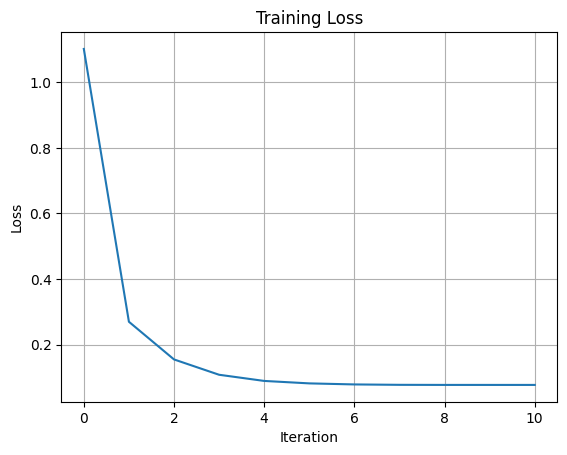

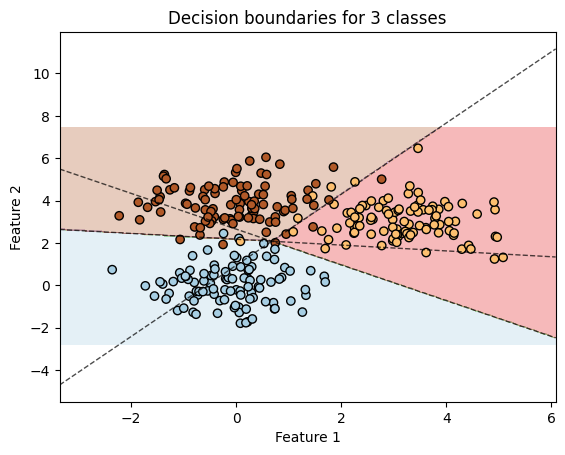

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

class SoftmaxRegression:
    def __init__(self, learning_rate=0.1, max_iter=1000, tol=1e-6, reg=0.0, method="gd"):
        """
        Multiclass logistic regression (softmax).
        
        Parameters
        ----------
        learning_rate : float
            Step size for gradient descent.
        max_iter : int
            Maximum iterations.
        tol : float
            Stopping criterion on gradient norm.
        reg : float
            L2 regularization strength (lambda). Bias row is NOT regularized.
        method : {'gd', 'newton'}
            Optimization method.
        """
        self.lr = float(learning_rate)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.reg = float(reg)
        self.method = method
        self.W = None
        self.loss_history = []
        self.classes_ = None

    @staticmethod
    def _softmax(S: np.ndarray) -> np.ndarray:
        # stable softmax
        S = S - np.max(S, axis=1, keepdims=True)
        expS = np.exp(S)
        return expS / np.sum(expS, axis=1, keepdims=True)

    def _one_hot(self, y: np.ndarray) -> np.ndarray:
        """One-hot with stable class mapping."""
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        class_to_index = {c: i for i, c in enumerate(self.classes_)}
        y_idx = np.array([class_to_index[c] for c in y], dtype=int)
        T = np.eye(len(self.classes_), dtype=float)[y_idx]
        return T

    def _loss_and_grad(self, X: np.ndarray, T: np.ndarray) -> tuple[float, np.ndarray, np.ndarray]:
        """Returns (loss, grad, P)."""
        N = X.shape[0]
        S = X @ self.W
        P = self._softmax(S)

        # Cross-entropy loss
        eps = 1e-15
        loss = -np.sum(T * np.log(P + eps)) / N

        # L2 regularization (do not regularize bias row 0)
        if self.reg > 0:
            W_no_bias = self.W[1:, :] if self.W.shape[0] > 1 else np.zeros((0, self.W.shape[1]))
            loss += 0.5 * self.reg * np.sum(W_no_bias ** 2)

        # Gradient: X^T(P - T) / N
        grad = (X.T @ (P - T)) / N
        if self.reg > 0 and self.W.shape[0] > 1:
            grad[1:, :] += self.reg * self.W[1:, :]

        return float(loss), grad, P

    def _hessian(self, X: np.ndarray, P: np.ndarray) -> np.ndarray:
        """Full Hessian of size (d*M) x (d*M) as block matrix."""
        N, d = X.shape
        M = P.shape[1]
        H = np.zeros((d * M, d * M), dtype=float)

        # Precompute x_i x_i^T for all i (small d in our demo, keep it simple)
        for i in range(N):
            xi = X[i]
            xxT = np.outer(xi, xi)  # d x d
            pi = P[i]  # length M
            for a in range(M):
                for b in range(M):
                    coeff = pi[a] * ((1.0 if a == b else 0.0) - pi[b])
                    block = coeff * xxT
                    ra = slice(a * d, (a + 1) * d)
                    cb = slice(b * d, (b + 1) * d)
                    H[ra, cb] += block

        H /= N

        # L2 regularization adds lambda * I (except bias coordinate inside each class block)
        if self.reg > 0:
            reg_diag = np.ones(d, dtype=float)
            reg_diag[0] = 0.0  # bias term
            for k in range(M):
                sl = slice(k * d, (k + 1) * d)
                H[sl, sl] += self.reg * np.diag(reg_diag)

        return H

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=float)
        T = self._one_hot(y)
        N, d = X.shape
        M = T.shape[1]

        self.W = np.random.randn(d, M) * 0.01
        self.loss_history = []

        for it in range(self.max_iter):
            loss, grad, P = self._loss_and_grad(X, T)
            self.loss_history.append(loss)

            grad_norm = float(np.linalg.norm(grad))
            if grad_norm < self.tol:
                print(f"Converged at iteration {it} (||grad||={grad_norm:.3e})")
                break

            if self.method == "gd":
                self.W -= self.lr * grad
            elif self.method == "newton":
                H = self._hessian(X, P)
                # Solve H * delta = grad_vec
                grad_vec = np.concatenate([grad[:, k] for k in range(M)], axis=0)
                # small damping for numerical stability
                damping = 1e-8
                H_damped = H + damping * np.eye(H.shape[0])
                try:
                    delta = np.linalg.solve(H_damped, grad_vec)
                except np.linalg.LinAlgError:
                    delta = np.linalg.pinv(H_damped) @ grad_vec

                # Update W from delta (stacked by classes)
                for k in range(M):
                    self.W[:, k] -= delta[k * d:(k + 1) * d]
            else:
                raise ValueError("method must be 'gd' or 'newton'")

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        S = X @ self.W
        return self._softmax(S)

    def predict(self, X: np.ndarray) -> np.ndarray:
        P = self.predict_proba(X)
        idx = np.argmax(P, axis=1)
        return self.classes_[idx]

# Generate synthetic data
N = 300
centers = [[0, 0], [3, 3], [0, 4]]
X, y = make_blobs(n_samples=N, centers=centers, n_features=2, cluster_std=0.9, random_state=42)

# Add bias term (first column 1)
X_b = np.c_[np.ones(X.shape[0]), X]

# Split
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# Train (try method='gd' or method='newton')
model = SoftmaxRegression(learning_rate=0.3, max_iter=200, tol=1e-6, reg=0.0, method="newton")
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

# Plot loss
plt.figure()
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

# Plot decision boundaries
plt.figure()
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]
Z = model.predict_proba(grid)
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.Paired)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundaries for 3 classes")

# Plot hyperplanes (decision lines between pairs of classes)
for i in range(model.W.shape[1]):
    for j in range(i + 1, model.W.shape[1]):
        w_diff = model.W[:, i] - model.W[:, j]
        # Decision line: w_diff^T x = 0
        # For 2D features (plus bias): w0 + w1*x1 + w2*x2 = 0
        if abs(w_diff[2]) > 1e-5:
            x1_vals = np.array([x_min, x_max])
            x2_vals = -(w_diff[0] + w_diff[1] * x1_vals) / w_diff[2]
            plt.plot(x1_vals, x2_vals, "k--", linewidth=1, alpha=0.7)
        else:
            # Vertical line if w2 ≈ 0
            if abs(w_diff[1]) > 1e-5:
                x1_val = -w_diff[0] / w_diff[1]
                plt.axvline(x=x1_val, color="k", linestyle="--", alpha=0.7)

plt.show()